In [1]:
import pandas as pd
file_path = r'/Users/misbahuddinalif/Downloads/Facebook.xlsx'
df = pd.read_excel(file_path)
df

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Total Reach,Total Impressions,Engaged Users,Post Consumers,Post Consumptions,Post Impressions by page audience,Post reach by page audience,Post engaged users by page audience,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85093,Photo,3,1,7,2,0.0,4684,7536,733,708,985,4750,2876,392,5,53.0,26.0,84
496,81370,Photo,2,1,5,8,0.0,3480,6229,537,508,687,3961,2104,301,0,53.0,22.0,75
497,81370,Photo,1,1,5,2,0.0,3778,7216,625,572,795,4742,2388,363,4,93.0,18.0,115
498,81370,Photo,3,1,4,11,0.0,4156,7564,626,574,832,4534,2452,370,7,91.0,38.0,136


# Data Cleaning

In [2]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [3]:
df.isna().mean()*100

page_total_likes                       0.0
type                                   0.0
category                               0.0
post_month                             0.0
post_weekday                           0.0
post_hour                              0.0
paid                                   0.2
total_reach                            0.0
total_impressions                      0.0
engaged_users                          0.0
post_consumers                         0.0
post_consumptions                      0.0
post_impressions_by_page_audience      0.0
post_reach_by_page_audience            0.0
post_engaged_users_by_page_audience    0.0
comment                                0.0
like                                   0.2
share                                  0.8
total_interactions                     0.0
dtype: float64

In [4]:
df.dtypes

page_total_likes                         int64
type                                       str
category                                 int64
post_month                               int64
post_weekday                             int64
post_hour                                int64
paid                                   float64
total_reach                              int64
total_impressions                        int64
engaged_users                            int64
post_consumers                           int64
post_consumptions                        int64
post_impressions_by_page_audience        int64
post_reach_by_page_audience              int64
post_engaged_users_by_page_audience      int64
comment                                  int64
like                                   float64
share                                  float64
total_interactions                       int64
dtype: object

In [5]:
df['paid'] = df['paid'].fillna(df['paid'].median())
df['like'] = df['like'].fillna(df['like'].median())
df['share'] = df['share'].fillna(df['share'].median())
df.isna().mean()*100

page_total_likes                       0.0
type                                   0.0
category                               0.0
post_month                             0.0
post_weekday                           0.0
post_hour                              0.0
paid                                   0.0
total_reach                            0.0
total_impressions                      0.0
engaged_users                          0.0
post_consumers                         0.0
post_consumptions                      0.0
post_impressions_by_page_audience      0.0
post_reach_by_page_audience            0.0
post_engaged_users_by_page_audience    0.0
comment                                0.0
like                                   0.0
share                                  0.0
total_interactions                     0.0
dtype: float64

# Model Training

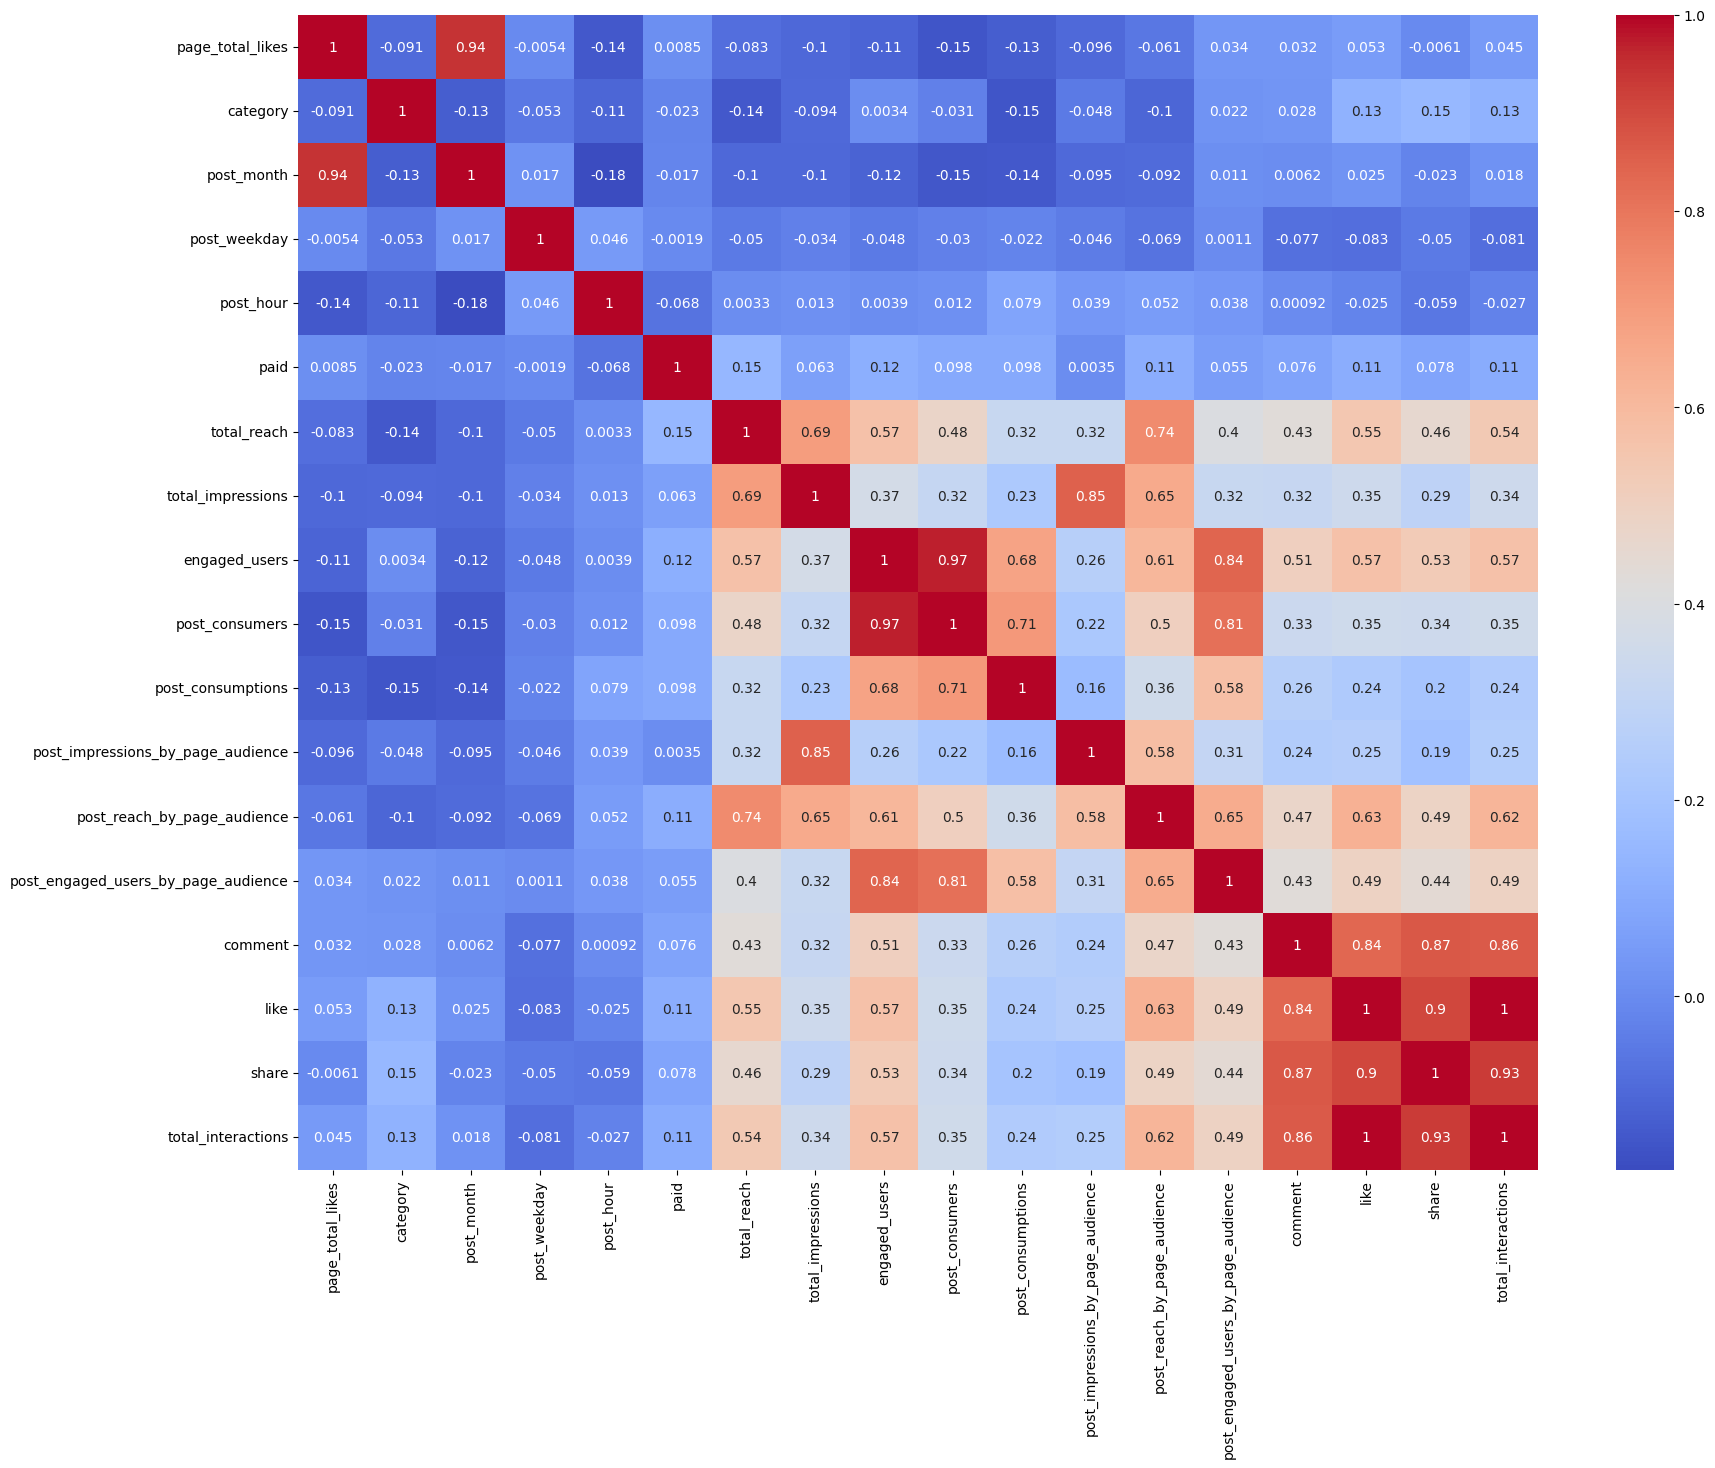

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [7]:
df.dtypes

page_total_likes                         int64
type                                       str
category                                 int64
post_month                               int64
post_weekday                             int64
post_hour                                int64
paid                                   float64
total_reach                              int64
total_impressions                        int64
engaged_users                            int64
post_consumers                           int64
post_consumptions                        int64
post_impressions_by_page_audience        int64
post_reach_by_page_audience              int64
post_engaged_users_by_page_audience      int64
comment                                  int64
like                                   float64
share                                  float64
total_interactions                       int64
dtype: object

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['total_reach', 'total_impressions', 'engaged_users', 'post_consumers', 'post_consumptions', 'post_impressions_by_page_audience', 'post_reach_by_page_audience', 'post_engaged_users_by_page_audience', 'comment', 'like', 'share'  ]]
y = df['total_interactions']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
model.score(X_test, y_test)*100

99.99342348304559

# Predicting the model

In [15]:
model.predict([[3500, 800, 2200, 400, 200, 120, 432, 532, 537, 675, 423]])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1676.92620263])

# dc

# DV

# MT